# S&P 500 Equity Option Analytics: Feature Evaluation

Univariate screening of the implied-volatility, realized-volatility, momentum
and quality features against the forward equity return declared at
`setup.yaml::labels.primary`, plus the GARCH estimators fitted upstream.
Produces the per-feature triage decisions the modeling notebooks record.

This is the **authoritative holdout-clean feature evaluation** that
`03_financial_features.py` and `04_model_based_features.py` defer to: every
statistic below is computed on the pre-2021 development window only, with the
2021 holdout sealed out (see "Seal the holdout window" below). The 2021 holdout
is spent once, on the single selected model in Ch11 onward.

**Learning Objectives**:
- Evaluate IV-derived features for standalone predictive power on equity returns
- Apply HAC adjustment for overlapping 5-day return autocorrelation
- Control false discovery rate with Benjamini-Hochberg correction
- Report weak standalone IC plainly rather than overstating marginal signal

**Book Reference**: §7.3 (univariate feature-label evaluation) and §7.4 (search
accounting and multiple testing). §8.6 is the secondary reference for search
control; §8.5 is about aggregating cross-cutting feature types and is not this
stage's chapter home.

**What it reads**: `features/financial.parquet`, `features/model_based.parquet`,
`labels/fwd_ret_5d.parquet`, and the evaluation block of `config/setup.yaml`.

**What it writes**: `evaluation/triage_ledger.parquet`, read by
`20_strategy_synthesis/02_feature_evaluation.py`, which puts the nine case
studies' screens side by side; and `evaluation/ic_timeseries.parquet`, plotted
below by the IC-through-time figure. Nothing else reads either artifact - the
model notebooks train on the full feature matrix and let regularization select,
so a STOP here is a recorded judgment about a feature, not a filter applied on
the reader's behalf.

**Prerequisites**: `03_financial_features.py` and `04_model_based_features.py`
must have run.

In [1]:
"""S&P 500 Equity Option Analytics: Feature Evaluation."""

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from plotly.subplots import make_subplots
from scipy.stats import spearmanr
from scipy.stats import t as student_t

import utils.style as style
from case_studies.utils.cv_window import modeling_fold_boundaries
from utils.cv_splits import load_evaluation_config
from utils.paths import display_path, get_case_study_dir

# Register the ML4T Plotly template (colorway, fonts, gridlines) as the default
# and expose the book palette so every figure sources color from utils.style.
style.apply_ml4t_style()
COLORS = style.COLORS
GRAY_FILLS = style.GRAY_FILLS


def _normalize_asset_column(df: pl.DataFrame) -> pl.DataFrame:
    if "symbol" in df.columns:
        return df
    msg = f"Expected asset-like column in frame, found columns={df.columns}"
    raise KeyError(msg)

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"

# Two kinds of constant, kept apart deliberately. The label, its horizon and the
# holdout boundary describe the case study and are read from
# `config/setup.yaml`, so a change there moves this notebook with it. The
# screening thresholds below them are this notebook's own judgment about what
# counts as enough coverage or enough stability; they belong to the screen rather
# than to the case study, and they are named here so the prose can refer to them
# instead of retyping their values.
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = setup["labels"]["primary"]
PRIMARY_LABEL_FILE = f"{PRIMARY_LABEL}.parquet"
# `5D` -> 5 sessions. The horizon sets both the embargo at the seal and the
# Newey-West bandwidth, which is why it is read once and spent twice.
LABEL_HORIZON_SESSIONS = int(str(setup["labels"]["horizons"][PRIMARY_LABEL]).rstrip("Dd"))
HAC_MAXLAGS = LABEL_HORIZON_SESSIONS

MIN_PERIODS = 20  # 415-634 symbols
# Screening thresholds, declared here and named in the prose rather than retyped.
COVERAGE_MIN = 0.70
STALENESS_MAX = 0.50
FDR_ALPHA = 0.05
SIGN_CONSISTENCY_MIN = 0.60
REDUNDANCY_CUT = 0.70
IC_THRESHOLD = 0.005  # Weekly horizon
# Metadata columns carried in the feature parquets that are not predictive
# features. `fold` is the one that matters: it is the third key of the temporal
# artifact, not a column to drop and forget - see section 0.
NON_FEATURE_COLS = {"fold", "is_holdout"}

## 0. Load Artifacts & Build Evaluation Panel

Three artifacts: the Ch8 financial features, the Ch9 temporal features, and
the primary label. The financial columns are deterministic transforms of
observable prices and surfaces, one row per `(timestamp, symbol)`, and they
join straight on.

**The temporal artifact does not.** Stage 04 fits GJR-GARCH per symbol *per
fold*, so `model_based.parquet` carries one row per `(timestamp, symbol,
fold)` - the same date and name three times, with three sets of fitted
parameters. Each fold's rows span its training window *and* its validation
window, and only the validation half is out of sample: inside the training
window the fitted value at a date was estimated from a span that includes that
date and everything after it up to the training end. The holdout fold is the
sharpest case - it trains through the last development session, so its rows
dated 2019 carry parameters that read 2020.

Joining that frame on `(timestamp, symbol)` alone does two things at once. It
**duplicates panel rows**, because the key is not unique on the right side, so
a name appears up to three times in the same cross-section and is counted
three times by every statistic below - including the staleness screen, which
sees the duplicates as adjacent identical rows and reads them as a column that
does not move. And it **mixes fold provenance**, because whichever of the
three rows a downstream cell reads may be an in-sample fitted value or a
forward-looking one.

So the temporal frame is restricted to each fold's validation window before it
is joined, and the restriction is asserted rather than assumed. The
consequence is that the GARCH columns exist only where a fold validated them,
which is the later part of the development window and not all of it - and the
screens in section 1 measure them on that window rather than against a
denominator they cannot reach.

In [4]:
features = _normalize_asset_column(pl.read_parquet(CASE_DIR / "features" / "financial.parquet"))
temporal = _normalize_asset_column(pl.read_parquet(CASE_DIR / "features" / "model_based.parquet"))

label_df = pl.read_parquet(CASE_DIR / "labels" / PRIMARY_LABEL_FILE)
label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol", "timestamp")][0]

cv_config = load_evaluation_config(CASE_STUDY_ID)

print(f"Features: {features.shape}")
print(f"Temporal: {temporal.shape}")
print(f"Labels: {label_df.shape}, column: {label_col}")

Features: (530503, 47)
Temporal: (1091740, 6)
Labels: (632522, 3), column: fwd_ret_5d


In [5]:
financial_cols = [c for c in features.columns if c not in JOIN_COLS and c not in NON_FEATURE_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS and c not in NON_FEATURE_COLS]

# The producer folds, from the generator stage 04 itself called, so the fold ids
# mean the same thing on both sides. The holdout fold stage 04 appends is not in
# this list and is therefore never selected here.
producer_folds = modeling_fold_boundaries(CASE_STUDY_ID, PRIMARY_LABEL)
if not producer_folds:
    msg = f"No canonical modeling folds for {CASE_STUDY_ID}/{PRIMARY_LABEL}"
    raise RuntimeError(msg)

temporal_oos = pl.concat(
    [
        temporal.filter(
            (pl.col("fold") == f["fold"])
            & (pl.col(DATE_COL) >= f["val_start"])
            & (pl.col(DATE_COL) <= f["val_end"])
        )
        for f in producer_folds
    ]
).drop("fold")
if temporal_oos.select(JOIN_COLS).n_unique() != len(temporal_oos):
    msg = "Fold validation windows overlap: the out-of-sample temporal frame is not one row per key"
    raise ValueError(msg)

# The window the temporal columns can be screened on. Outside it they are absent
# by construction rather than missing, and section 1 divides by this rather than
# by the whole development panel.
TEMPORAL_WINDOW = (
    min(f["val_start"] for f in producer_folds),
    max(f["val_end"] for f in producer_folds),
)

for f in producer_folds:
    print(
        f"temporal fold {f['fold']}: fitted {f['train_start']} to {f['train_end']}, "
        f"kept {f['val_start']} to {f['val_end']}"
    )
print(
    f"Temporal rows: {len(temporal):,} across folds -> {len(temporal_oos):,} out of sample "
    f"({TEMPORAL_WINDOW[0]} to {TEMPORAL_WINDOW[1]})"
)

# Join: features + out-of-sample temporal + labels. The left join cannot now
# change the row count, and that is asserted rather than trusted.
eval_panel = features.join(temporal_oos, on=JOIN_COLS, how="left")
if len(eval_panel) != len(features):
    msg = f"Temporal join changed the panel row count: {len(features):,} -> {len(eval_panel):,}"
    raise ValueError(msg)
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")

all_feature_cols = financial_cols + temporal_cols

if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

temporal fold 0: fitted 2018-01-04 to 2019-12-18, kept 2020-01-06 to 2020-12-23
temporal fold 1: fitted 2017-01-05 to 2018-12-19, kept 2019-01-07 to 2020-01-03
Temporal rows: 1,091,740 across folds -> 230,925 out of sample (2019-01-07 to 2020-12-23)


### Seal the holdout window

03 and 04 defer to this notebook as *the authoritative holdout-clean feature
evaluation*. To honor that, every statistic below (coverage/staleness, IC, HAC,
FDR, fold stability, triage) is computed on the **development window only** --
sessions strictly before the 2021 holdout, with the final
`LABEL_HORIZON_SESSIONS` dev sessions embargoed so no 5-day forward label
reaches across the seal. The 2021 holdout is never read here; it is spent once,
on the single selected model in Ch11 onward.

In [6]:
from datetime import date as _date

holdout_start = str(cv_config["holdout_start"])[:10]
holdout_start_date = _date.fromisoformat(holdout_start)

dev_sessions = eval_panel.filter(pl.col(DATE_COL) < holdout_start_date)[DATE_COL].unique().sort()
if dev_sessions.len() > LABEL_HORIZON_SESSIONS:
    embargo_cutoff = dev_sessions[-(LABEL_HORIZON_SESSIONS + 1)]
    eval_panel = eval_panel.filter(pl.col(DATE_COL) <= embargo_cutoff)
else:
    eval_panel = eval_panel.filter(pl.col(DATE_COL) < holdout_start_date)

print(
    f"Holdout sealed at {holdout_start}: evaluating "
    f"{eval_panel[DATE_COL].min()} -> {eval_panel[DATE_COL].max()} "
    f"({eval_panel[DATE_COL].n_unique():,} dev sessions, "
    f"{LABEL_HORIZON_SESSIONS}-session label embargo)"
)

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(f"\nEval panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} dates")
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Holdout sealed at 2021-01-01: evaluating 2017-01-03 -> 2020-12-23 (1,002 dev sessions, 5-session label embargo)

Eval panel: 421,293 rows, 609 symbols, 1,002 dates
Features: 45 financial + 3 temporal = 48 total
Label: fwd_ret_5d


## Artifact Quality Gate

Verify upstream artifacts are free of critical defects before evaluation. This is
the artifact gate - infinities, negative prices, extreme returns - and it asks a
different question from the per-feature coverage and staleness screens below.

In [7]:
from utils.data_quality import validate_modeling_inputs

validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    # An order-of-magnitude tripwire on the label, not a bound on what a small cap
    # can do over five sessions: it fires on a corrupted price series, and the
    # observed extreme sits far inside it.
    max_abs_return=10.0,
    fail_on_critical=True,
)

Data Quality Gate: ALL CLEAR


{'issues': [], 'n_critical': 0, 'n_warning': 0}

## 1. Correctness Screens

Check coverage and staleness before evaluating predictive power. These are two of
the four correctness questions book §7.3 lists; timing and lag consistency, and
mask alignment, are settled upstream where each family's lag is declared.

IV features have reduced coverage for less-liquid names, and the one-session IV
lag makes every IV feature carry a repeated value on any session the surface did
not update. Both are properties of the data rather than errors, which is exactly
why the screen has to be a gate rather than a judgement call: a feature clears
when its coverage reaches `COVERAGE_MIN` and its staleness stays at or below
`STALENESS_MAX`, and the figure below shows where every candidate sits against
those two bounds rather than printing only the ones that failed.

**Each column is screened on the window it can reach.** For the financial
columns that is every development session. For the three GARCH columns it is
the union of the producer folds' validation windows, because outside that
window stage 04 produces no out-of-sample fitted value and the column is
absent by construction rather than missing. Dividing those by the whole
development panel would report a structural property of the fold contract as
though it were a data-quality failure, and the gate would then remove them for
a reason that is not true of them.

In [8]:
coverage = {}
staleness = {}

# The rows each column is eligible on. Temporal columns exist only inside the
# producer folds' validation windows; everything else spans the panel.
eligible_rows = {}
for feat in all_feature_cols:
    if feat in temporal_cols:
        eligible_rows[feat] = eval_panel.filter(
            (pl.col(DATE_COL) >= TEMPORAL_WINDOW[0]) & (pl.col(DATE_COL) <= TEMPORAL_WINDOW[1])
        )
    else:
        eligible_rows[feat] = eval_panel

for feat in all_feature_cols:
    frame = eligible_rows[feat]
    denom = len(frame)
    coverage[feat] = frame[feat].drop_nulls().len() / denom

    unchanged = (
        frame.sort(JOIN_COLS)
        .select((pl.col(feat) == pl.col(feat).shift(1).over("symbol")).alias("same"))["same"]
        .sum()
    )
    staleness[feat] = float(unchanged) / max(denom - frame["symbol"].n_unique(), 1)

correctness = {
    feat: coverage[feat] >= COVERAGE_MIN and staleness[feat] <= STALENESS_MAX
    for feat in all_feature_cols
}
n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Gate: coverage >= {COVERAGE_MIN:.0%}, staleness <= {STALENESS_MAX:.0%}")
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [round(coverage[f], 3) for f, ok in correctness.items() if not ok],
            "staleness": [round(staleness[f], 3) for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Gate: coverage >= 70%, staleness <= 50%
Correctness gate: 35 PASS, 13 FAIL
shape: (13, 3)
┌─────────────────────┬──────────┬───────────┐
│ feature             ┆ coverage ┆ staleness │
│ ---                 ┆ ---      ┆ ---       │
│ str                 ┆ f64      ┆ f64       │
╞═════════════════════╪══════════╪═══════════╡
│ iv_90_atm           ┆ 0.63     ┆ 0.104     │
│ qc_converged_share  ┆ 0.908    ┆ 0.882     │
│ term_slope_near_atm ┆ 0.699    ┆ 0.198     │
│ term_slope_far_atm  ┆ 0.484    ┆ 0.112     │
│ term_ratio_atm      ┆ 0.444    ┆ 0.163     │
│ …                   ┆ …        ┆ …         │
│ iv_30_atm_z_252     ┆ 0.415    ┆ 0.0       │
│ skew_rr_z_63        ┆ 0.547    ┆ 0.0       │
│ iv_30_atm_pct_252   ┆ 0.415    ┆ 0.004     │
│ term_ratio_z_63     ┆ 0.025    ┆ 0.0       │
│ vrp_z_63            ┆ 0.537    ┆ 0.0       │
└─────────────────────┴──────────┴───────────┘


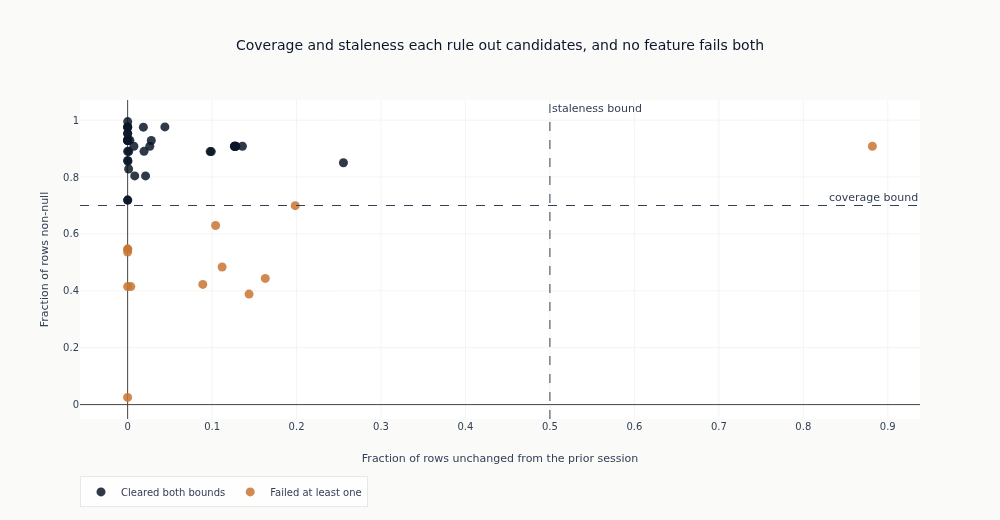

Failed on staleness alone: 1
Failed on coverage alone:  12
Failed on both:            0


In [9]:
gate_x = [staleness[f] for f in all_feature_cols]
gate_y = [coverage[f] for f in all_feature_cols]
fig = go.Figure()
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared both bounds"),
    (False, COLORS["copper"], "Failed at least one"),
):
    members = [f for f in all_feature_cols if correctness[f] is cleared]
    if not members:
        continue
    _ = fig.add_trace(
        go.Scatter(
            x=[staleness[f] for f in members],
            y=[coverage[f] for f in members],
            mode="markers",
            marker={"color": color, "size": 9, "opacity": 0.85},
            text=members,
            name=name,
        )
    )
_ = fig.add_hline(
    y=COVERAGE_MIN,
    line={"color": COLORS["neutral"], "width": 1, "dash": "dash"},
    annotation_text="coverage bound",
)
_ = fig.add_vline(
    x=STALENESS_MAX,
    line={"color": COLORS["neutral"], "width": 1, "dash": "dash"},
    annotation_text="staleness bound",
)
fig.update_layout(
    title="Coverage and staleness each rule out candidates, and no feature fails both",
    xaxis_title="Fraction of rows unchanged from the prior session",
    yaxis_title="Fraction of rows non-null",
    height=520,
    width=1000,
    legend={"orientation": "h", "y": -0.18},
)
fig.show()
only_staleness = sum(
    1
    for f in all_feature_cols
    if not correctness[f] and coverage[f] >= COVERAGE_MIN and staleness[f] > STALENESS_MAX
)
only_coverage = sum(
    1
    for f in all_feature_cols
    if not correctness[f] and coverage[f] < COVERAGE_MIN and staleness[f] <= STALENESS_MAX
)
print(f"Failed on staleness alone: {only_staleness}")
print(f"Failed on coverage alone:  {only_coverage}")
print(f"Failed on both:            {n_fail - only_staleness - only_coverage}")

## 2. Univariate Association (IC + HAC)

Cross-sectional Spearman IC at every session, averaged, with a Newey-West
correction over `HAC_MAXLAGS` lags - the label's own horizon, because consecutive
forward returns of that horizon overlap and their ICs are serially dependent by
construction. The series is sorted on the time axis before it reaches the
estimator. Date-level features (identical across symbols) produce zero
cross-sectional IC by construction and are flagged separately.

In [10]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# Detect date-level features (zero cross-sectional variance)
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

In [11]:
# Batch IC computation: one pass over dates, all features at once
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col])

dates_list = eval_sub[DATE_COL].unique().sort().to_list()
n_total = len(dates_list)

ic_series_data = {feat: [] for feat in cs_features}

for i, dt in enumerate(dates_list):
    cross_section = eval_sub.filter(pl.col(DATE_COL) == dt)
    n_obs = len(cross_section)
    if n_obs < MIN_PERIODS:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_PERIODS:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 200 == 0:
        print(f"  IC progress: {i + 1}/{n_total} dates")

print(f"  IC progress: {n_total}/{n_total} dates (done)")

  IC progress: 200/1002 dates


  IC progress: 400/1002 dates


  IC progress: 600/1002 dates


  IC progress: 800/1002 dates


  IC progress: 1000/1002 dates
  IC progress: 1002/1002 dates (done)


In [12]:
# Convert to DataFrames and compute HAC stats
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < 20:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=False)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)})
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"IC computed for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

IC computed for 35 cross-sectional features
Skipped 0 date-level features


### The IC Series Itself

The mean IC is a scalar summary of a series, and the two patterns that decide
whether a weak association is usable are visible only in the series: an IC carried
by one episode, and an IC that changes sign. The left panel draws the daily IC of
the leading feature under a rolling mean; the right panel puts three ways of
bounding the mean on one axis for the leading features - the naive interval that
assumes independent sessions, the Newey-West interval that does not, and the
block-bootstrap bounds that assume neither a variance formula nor a distribution.
With a five-session label the sessions overlap heavily, so the gap between the
grey band and the navy bar is the cost of pretending otherwise. That cost is
not cosmetic: the one leading feature whose naive interval sits entirely below
zero has a Newey-West interval that crosses it.

The series drawn here is the one the notebook later writes to
`evaluation/ic_timeseries.parquet`, so the artifact is not written for nobody:
the figure is its first reader, in memory, and the parquet is the same values
on disk for anyone who wants them at a different grain.

In [13]:
IC_ROLLING_WINDOW = 63  # one quarter of sessions
BOOT_BOUNDS = ("ci_boot_lower", "ci_boot_upper")

leaders = sorted(ic_results, key=lambda name: abs(ic_results[name]["mean_ic"]), reverse=True)[:8]
# `compute_ic_uncertainty` sets its lag to `horizon - 1` and its bootstrap block
# to `horizon`, both counted in observations of the series it is handed. Passing
# one more than `HAC_MAXLAGS` gives the bands the same bandwidth the IC table
# above uses, so the figure and the table are the same correction read two ways.
ic_uncertainty = {
    feature: compute_ic_uncertainty(ic_timeseries[feature], horizon=HAC_MAXLAGS + 1, ic_col="ic")
    for feature in leaders
}
leader = leaders[0] if leaders else None
print(f"Leading feature by absolute mean IC: {leader}")

Leading feature by absolute mean IC: mom_5d


In [14]:
def interval_arms(features: list[str], lower: str, upper: str) -> dict:
    """Asymmetric Plotly error bars from a pair of interval bounds."""
    return {
        "type": "data",
        "symmetric": False,
        "array": [
            ic_uncertainty[name][upper] - ic_uncertainty[name]["mean_ic"] for name in features
        ],
        "arrayminus": [
            ic_uncertainty[name]["mean_ic"] - ic_uncertainty[name][lower] for name in features
        ],
    }

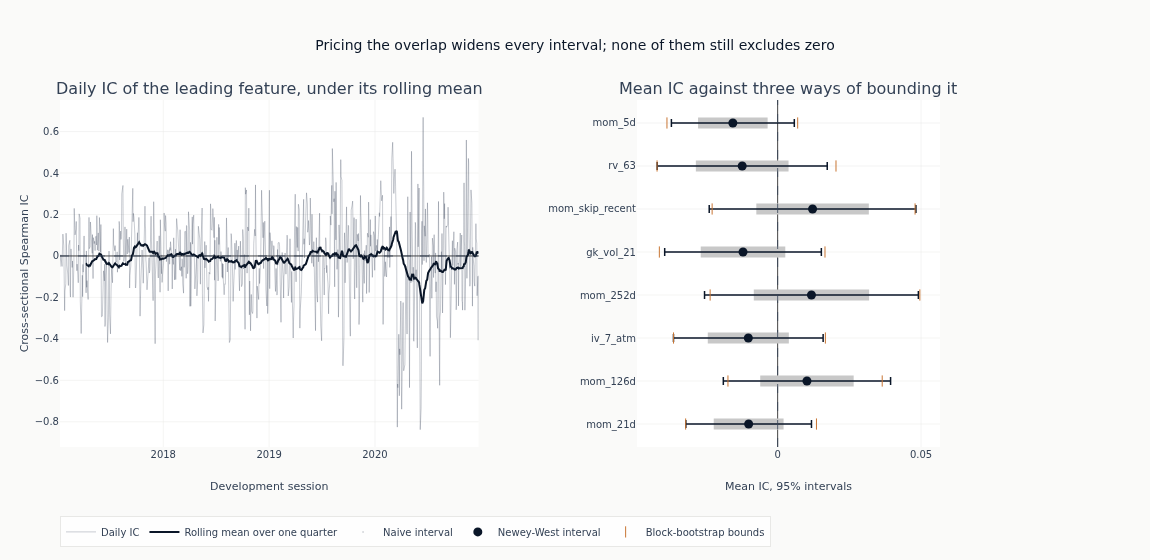

In [15]:
if leader:
    leader_series = (
        ic_timeseries[leader]
        .sort(DATE_COL)
        .with_columns(pl.col("ic").rolling_mean(IC_ROLLING_WINDOW).alias("rolling"))
    )
    interval_features = list(reversed(leaders))
    interval_means = [ic_uncertainty[name]["mean_ic"] for name in interval_features]
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.58, 0.42],
        subplot_titles=(
            "Daily IC of the leading feature, under its rolling mean",
            "Mean IC against three ways of bounding it",
        ),
        horizontal_spacing=0.18,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["ic"],
            mode="lines",
            line={"color": COLORS["neutral"], "width": 0.6},
            opacity=0.45,
            name="Daily IC",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["rolling"],
            mode="lines",
            line={"color": COLORS["blue"], "width": 2},
            name="Rolling mean over one quarter",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_hline(
        y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 1, "opacity": 0.0},
            error_x=interval_arms(interval_features, "ci_naive_lower", "ci_naive_upper")
            | {"color": GRAY_FILLS["tertiary"], "thickness": 11, "width": 0},
            name="Naive interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 9},
            error_x=interval_arms(interval_features, "ci_hac_lower", "ci_hac_upper")
            | {"color": COLORS["blue"], "thickness": 1.5},
            name="Newey-West interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[ic_uncertainty[name][bound] for name in interval_features for bound in BOOT_BOUNDS],
            y=[name for name in interval_features for _ in BOOT_BOUNDS],
            mode="markers",
            marker={"color": COLORS["copper"], "size": 8, "symbol": "line-ns-open"},
            name="Block-bootstrap bounds",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_vline(
        x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=2
    )
    fig.update_layout(
        title="Pricing the overlap widens every interval; none of them still excludes zero",
        height=560,
        width=1150,
        margin={"l": 60, "r": 210},
        legend={"orientation": "h", "y": -0.2},
    )
    fig.update_yaxes(title_text="Cross-sectional Spearman IC", row=1, col=1)
    fig.update_xaxes(title_text="Development session", row=1, col=1)
    fig.update_xaxes(title_text="Mean IC, 95% intervals", row=1, col=2)
    fig.show()

### Fold-Level Stability

Sign consistency across the walk-forward folds. A feature whose IC flips sign
between folds is unreliable regardless of its full-sample t-statistic.

**Where the boundaries come from.** One live source, the same one section 0
used to decide which temporal rows are out of sample:
`modeling_fold_boundaries`, which is what stage 04 itself called. The earlier
form of this cell looked for a materialized `splits` array on the evaluation
config and cut the development window into equal halves when it found none -
which it always did, because `load_evaluation_config` returns the declared
geometry and not its expansion. Halves are not folds: they ignore
`train_size`, `val_size` and the label buffer, so a statistic computed over
them is not the one the prose claims. The consequence of using the real folds
is that stability is measured on the validation windows only, which is the
later part of the development window and not all of it, and the overall IC in
section 2 spans more sessions than these folds do.

With the two folds `setup.yaml::evaluation.n_splits` declares, sign consistency
takes only the values zero, one half and one, so a quartile across the folds is
not a quantity worth reporting - the figure shows the fold means themselves.
It also means `SIGN_CONSISTENCY_MIN` is not a proportion here but a yes or no:
a feature clears the stability arm exactly when both folds agree. Two folds is
a weak test of stability, and the count is printed below rather than left to be
inferred from the ledger's `sign_consistency` column.

Sign consistency is measured **against the feature's own direction**, not
against positive. A candidate negative in every fold is as consistent as one
positive in every fold; scoring the share of *positive* folds would have made
the stability arm unreachable for every negative-IC feature, which is a rule
about sign rather than about stability.

In [16]:
fold_boundaries = [(f["val_start"], f["val_end"]) for f in producer_folds]
for i, f in enumerate(producer_folds, start=1):
    print(
        f"fold {i}: fitted {f['train_start']} to {f['train_end']}, "
        f"validated {f['val_start']} to {f['val_end']}"
    )
if max(end for _, end in fold_boundaries) >= holdout_start_date:
    msg = "A validation fold ends at or after the holdout boundary"
    raise ValueError(msg)

fold_stats = {}
for feat in ic_results:
    fold_ics = []
    ts = ic_timeseries[feat]
    for fold_start, fold_end in fold_boundaries:
        fold_ic = ts.filter((pl.col(DATE_COL) >= fold_start) & (pl.col(DATE_COL) <= fold_end))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        # Direction from the feature's own overall estimate, then the share of
        # folds that agree with it. `worst_fold_ic` is likewise the fold
        # furthest against that direction, not the raw minimum, which for a
        # negative-IC feature is its *best* fold.
        direction = 1.0 if (ic_results[feat]["mean_ic"] or 0.0) >= 0 else -1.0
        signed = [ic * direction for ic in fold_ics]
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sum(1 for s in signed if s > 0) / len(fold_ics),
            "worst_fold_ic": fold_ics[int(np.argmin(signed))],
            "best_fold_ic": fold_ics[int(np.argmax(signed))],
            "median_fold_ic": float(np.median(fold_ics)),
            "fold_ics": fold_ics,
        }

n_consistent = sum(
    1 for stats in fold_stats.values() if stats["sign_consistency"] >= SIGN_CONSISTENCY_MIN
)
print(f"Fold stability computed for {len(fold_stats)} features")
print(f"Sign consistency at or above {SIGN_CONSISTENCY_MIN:.0%}: {n_consistent}/{len(fold_stats)}")

fold 1: fitted 2018-01-04 to 2019-12-18, validated 2020-01-06 to 2020-12-23
fold 2: fitted 2017-01-05 to 2018-12-19, validated 2019-01-07 to 2020-01-03
Fold stability computed for 35 features
Sign consistency at or above 60%: 13/35


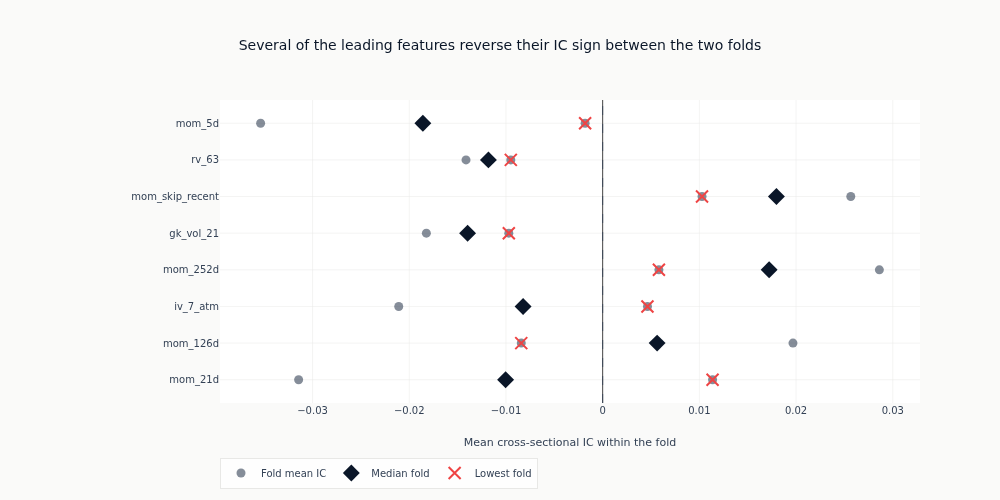

In [17]:
stability_features = [name for name in reversed(leaders) if name in fold_stats]
if stability_features:
    fig = go.Figure()
    _ = fig.add_trace(
        go.Scatter(
            x=[value for name in stability_features for value in fold_stats[name]["fold_ics"]],
            y=[name for name in stability_features for _ in fold_stats[name]["fold_ics"]],
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 9, "opacity": 0.6},
            name="Fold mean IC",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["median_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 13, "symbol": "diamond"},
            name="Median fold",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["worst_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={
                "color": COLORS["negative"],
                "size": 12,
                "symbol": "x-thin",
                "line": {"width": 2, "color": COLORS["negative"]},
            },
            name="Lowest fold",
        )
    )
    _ = fig.add_vline(x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
    fig.update_layout(
        title="Several of the leading features reverse their IC sign between the two folds",
        xaxis_title="Mean cross-sectional IC within the fold",
        height=500,
        width=1000,
        margin={"l": 220},
        legend={"orientation": "h", "y": -0.18},
    )
    fig.show()

## 3. Search Accounting and Multiple Testing

**The searched set.** A p-value means nothing without the set of tests it came
out of, so the set is declared before the adjustment is applied. It is the
implied-volatility, realized-volatility, variance-risk-premium, momentum and
quality features `03_financial_features` generates, plus the GARCH estimators
`04_model_based_features` fits, restricted to those clearing the correctness
screen above. Generation is blind to the label: nothing here was added after
seeing an IC. Only the primary label is screened; the other declared horizons are
not tested, so they do not enter the count.

**The adjustment.** Benjamini-Hochberg at `FDR_ALPHA` across that set. Testing
each candidate at the same nominal level would let the expected count of false
positives grow with the size of the set; BH controls the expected share of false
discoveries among the features it rejects instead. The expected false-positive
count under the unadjusted rule is printed with the three significance counts.

Few or no features clearing the adjustment is a plausible reading of this case
study rather than a failure of the screen. Implied volatility predicts future
realized volatility; it is not a directional signal on the underlying equity, and
whatever it contributes is expected to appear in a multivariate fit.

In [18]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": [float(p) for p in fdr_result["adjusted_p_values"]],
        "fdr_sig": [bool(r) for r in fdr_result["rejected"]],
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

# The naive tier has to actually be naive. `compute_ic_hac_stats` returns the
# Newey-West p-value and the naive t-statistic; reading the first as if it were the
# unadjusted one makes the inflation ratio a comparison of a quantity with itself.
naive_p_values = [
    float(2 * student_t.sf(abs(ic_results[f]["naive_t_stat"]), df=ic_results[f]["n_periods"] - 1))
    for f in feature_names
]
n_searched = len(feature_names)
expected_false_positives = FDR_ALPHA * n_searched

n_significant_naive = sum(1 for p in naive_p_values if p < FDR_ALPHA)
n_significant_hac = sum(1 for p in p_values if p < FDR_ALPHA)
n_significant_fdr = int(fdr_result["n_rejected"])


def inflation(naive_count: int, adjusted_count: int) -> str:
    """How much the unadjusted count overstates the adjusted one.

    Undefined when the adjustment rejects nothing: substituting one for a zero
    denominator reports a finite ratio where none exists, and the reader cannot
    tell the substitution from a measurement.
    """
    if adjusted_count == 0:
        return "undefined (the adjustment rejected nothing)"
    return f"{naive_count / adjusted_count:.2f}x"


print(f"Searched set: {n_searched} features with a computable IC on {label_col}")
print(f"Expected false positives at the unadjusted level: {expected_false_positives:.1f}")
print(f"Naive significant:            {n_significant_naive}")
print(f"Newey-West significant:       {n_significant_hac}")
print(f"BH-FDR significant:           {n_significant_fdr}")
print(f"Inflation factor (Newey-West): {inflation(n_significant_naive, n_significant_hac)}")
print(f"Inflation factor (BH-FDR):     {inflation(n_significant_naive, n_significant_fdr)}")

Searched set: 35 features with a computable IC on fwd_ret_5d
Expected false positives at the unadjusted level: 1.8
Naive significant:            2
Newey-West significant:       0
BH-FDR significant:           0
Inflation factor (Newey-West): undefined (the adjustment rejected nothing)
Inflation factor (BH-FDR):     undefined (the adjustment rejected nothing)


### Ranking, with the Inference Adjustment Visible

The left panel ranks the leading features by absolute mean IC, coloured by whether
each cleared the false-discovery adjustment. The right panel plots the Newey-West
t-statistic against its unadjusted twin for every feature in the searched set: a
point pulled toward zero off the diagonal is a feature whose apparent significance
came from the overlap between consecutive five-session returns rather than from
the size of its IC. Bars run horizontally; at this many feature names a rotated
vertical axis is not legible.

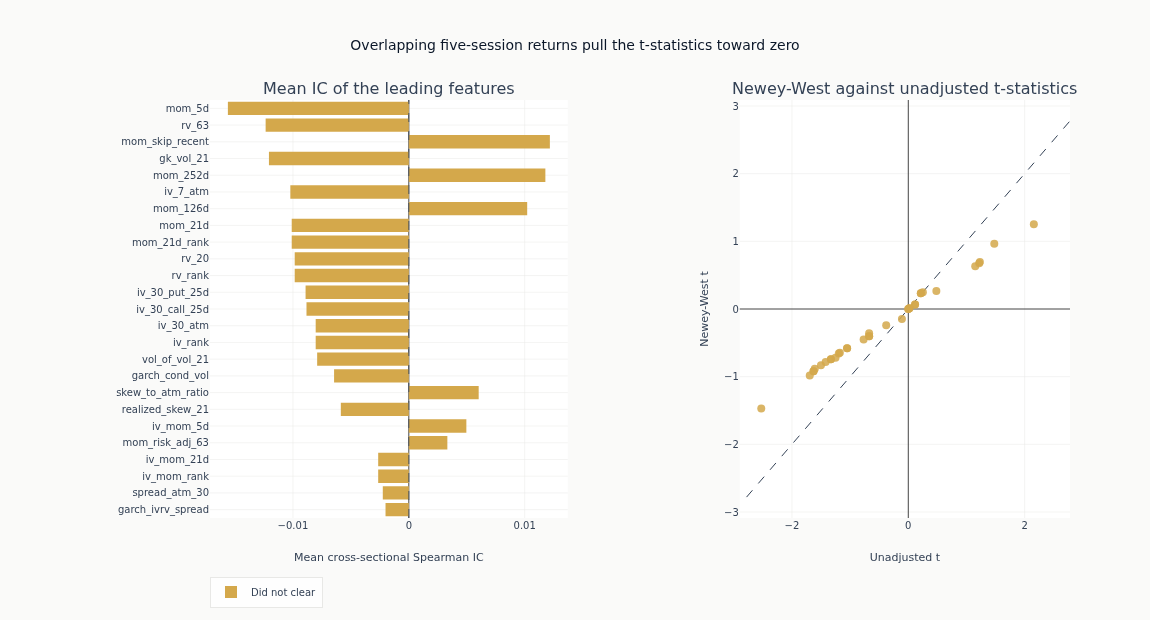

In [19]:
RANKED_FEATURES = 25
top = eval_summary.head(min(RANKED_FEATURES, len(eval_summary))).reverse()

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.52, 0.48],
    subplot_titles=[
        "Mean IC of the leading features",
        "Newey-West against unadjusted t-statistics",
    ],
    horizontal_spacing=0.2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = top.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Bar(
            x=arm["ic_mean"].to_list(),
            y=arm["feature"].to_list(),
            orientation="h",
            marker_color=color,
            name=name,
        ),
        row=1,
        col=1,
    )
_ = fig.add_vline(
    x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
)

max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
_ = fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line={"dash": "dash", "color": COLORS["neutral"], "width": 1},
        showlegend=False,
    ),
    row=1,
    col=2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = eval_summary.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Scatter(
            x=arm["naive_t"].to_list(),
            y=arm["hac_t"].to_list(),
            mode="markers",
            marker={"color": color, "size": 8, "opacity": 0.85},
            text=arm["feature"].to_list(),
            name=name,
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_layout(
    title="Overlapping five-session returns pull the t-statistics toward zero",
    height=620,
    width=1150,
    margin={"l": 210},
    legend={"orientation": "h", "y": -0.14},
)
# Two traces split the ranking by outcome, so the y order has to be restated or the
# categories fall in trace order and the ranking the panel exists to show is lost.
fig.update_yaxes(categoryorder="array", categoryarray=top["feature"].to_list(), row=1, col=1)
fig.update_xaxes(title_text="Mean cross-sectional Spearman IC", row=1, col=1)
fig.update_xaxes(title_text="Unadjusted t", row=1, col=2)
fig.update_yaxes(title_text="Newey-West t", row=1, col=2)
fig.show()

## 4. Shape Diagnostics

Does the mean forward return spread monotonically across feature quintiles? A
monotone profile is compatible with the ranking-based mapping the strategy
applies; a high IC with a flat or U-shaped profile is not, and usually means the
correlation is outlier-driven.

**How the bins are assigned, and what that costs.** The edges come from the
pooled development sample rather than from within each session, so a bar mixes
cross-sectional position with time-series level and every other session's
distribution helps set this session's edges. Book §7.3 specifies the within-date
construction, which is what the companion IC already uses. The divergence moves
the `monotonicity` column of the ledger and is tracked in the stage-05 notebook
standard rather than changed here. Read the profiles below as pooled shape, not
as a within-session sort.

In [20]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]
if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}

for feat in top_features_for_shape:
    valid = eval_panel.select([feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue

    valid = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=[f"Q{i + 1}" for i in range(N_QUANTILES)])
        .alias("quantile")
    )
    q_means = valid.group_by("quantile").agg(pl.col(label_col).mean()).sort("quantile")
    means = q_means[label_col].to_list()
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

print(f"Shape analysis for {len(quantile_spreads)} features")

Shape analysis for 10 features


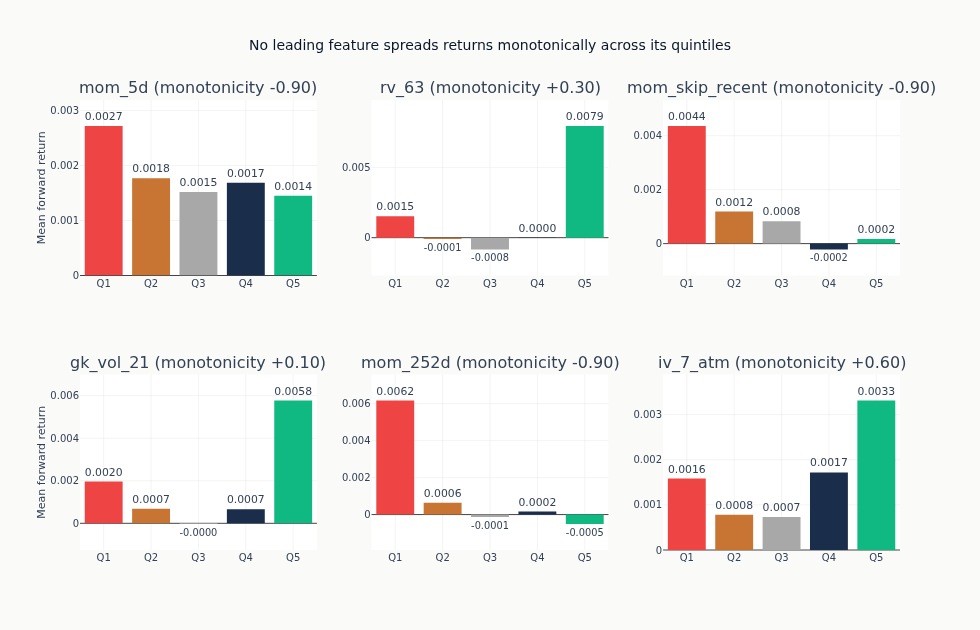

Quintile spread, Q5 minus Q1, per feature:
  mom_5d                       spread=-0.00127  monotonicity=-0.90
  rv_63                        spread=+0.00643  monotonicity=+0.30
  mom_skip_recent              spread=-0.00418  monotonicity=-0.90
  gk_vol_21                    spread=+0.00381  monotonicity=+0.10
  mom_252d                     spread=-0.00667  monotonicity=-0.90
  iv_7_atm                     spread=+0.00173  monotonicity=+0.60


In [21]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(
        rows=n_rows_fig,
        cols=3,
        subplot_titles=[
            f"{feat} (monotonicity {monotonicity_scores[feat]:+.2f})" for feat in feats_to_show
        ],
        vertical_spacing=0.22,
    )
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        q_means = quantile_spreads[feat]["q_means"]
        _ = fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=[
                    COLORS["negative"],
                    COLORS["copper"],
                    GRAY_FILLS["muted"],
                    COLORS["slate"],
                    COLORS["positive"],
                ],
                showlegend=False,
                text=[f"{m:.4f}" for m in q_means],
                textposition="outside",
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        title="No leading feature spreads returns monotonically across its quintiles",
        height=270 * n_rows_fig + 90,
        width=980,
    )
    fig.update_yaxes(title_text="Mean forward return", col=1)
    fig.show()
    print("Quintile spread, Q5 minus Q1, per feature:")
    for feat in feats_to_show:
        print(
            f"  {feat:28s} spread={quantile_spreads[feat]['spread']:+.5f}"
            f"  monotonicity={monotonicity_scores[feat]:+.2f}"
        )

## 5. Redundancy & Feature Families

In [22]:
def assign_feature_family(col: str) -> str:
    """Map feature name to family - canonical prefix-based logic matching 03_financial_features.py."""
    if col.startswith(("iv_30", "iv_7", "iv_90", "d_iv", "iv_mom")):
        return "iv_level_dynamics"
    elif col.startswith(("skew", "term", "iv_30_put", "iv_30_call")):
        return "skew_term"
    elif col.startswith(("rv_", "ivrv", "vrp", "gk_vol", "vol_of_vol", "realized_skew")):
        return "vrp"
    elif col.endswith("_rank"):
        return "cross_sectional_rank"
    elif col.startswith("mom_"):
        return "momentum"
    elif col.startswith(("qc_", "spread_")):
        return "quality"
    elif col.startswith("garch_"):
        return "temporal_garch"
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

for feat in temporal_cols:
    families[feat] = assign_feature_family(feat)

In [23]:
# Pairwise correlation
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features).to_pandas()
)
corr_matrix = corr_data.corr(method="spearman")

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT:
            high_corr_pairs.append((cols[i], cols[j], float(corr_matrix.iloc[i, j])))

print(f"Redundancy cut: |rank correlation| > {REDUNDANCY_CUT}")
print(f"Feature pairs above the cut: {len(high_corr_pairs)}")

Redundancy cut: |rank correlation| > 0.7
Feature pairs above the cut: 41


In [24]:
# Family-level IC summary
family_ic = {}
fdr_sig_set = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_set,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
    print(fam_df)
else:
    fam_df = pl.DataFrame()
    print("No features passed IC evaluation threshold")

shape: (8, 5)
┌──────────────────────┬────────────┬────────────┬───────────┬───────────┐
│ family               ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---                  ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str                  ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞══════════════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ momentum             ┆ 7          ┆ 0.009149   ┆ 0.0018    ┆ 0         │
│ vrp                  ┆ 8          ┆ 0.007238   ┆ -0.007238 ┆ 0         │
│ cross_sectional_rank ┆ 3          ┆ 0.006322   ┆ -0.005774 ┆ 0         │
│ iv_level_dynamics    ┆ 9          ┆ 0.005278   ┆ -0.003898 ┆ 0         │
│ temporal_garch       ┆ 3          ┆ 0.00331    ┆ -0.00233  ┆ 0         │
│ quality              ┆ 1          ┆ 0.002246   ┆ -0.002246 ┆ 0         │
│ skew_term            ┆ 3          ┆ 0.002048   ┆ 0.002048  ┆ 0         │
│ other                ┆ 1          ┆ 0.000212   ┆ -0.000212 ┆ 0         │
└──────────

### The Strongest Redundant Pairs

Ranked pairs rather than the full matrix: the question the section asks is which
two candidates are the same evidence entered twice, and a full heatmap answers it
only if the reader can still read the tick labels. Each bar names both members
and the family each belongs to, so a pair inside one family and a pair spanning
two are distinguishable - the second kind is what a family-by-family selection
would miss.

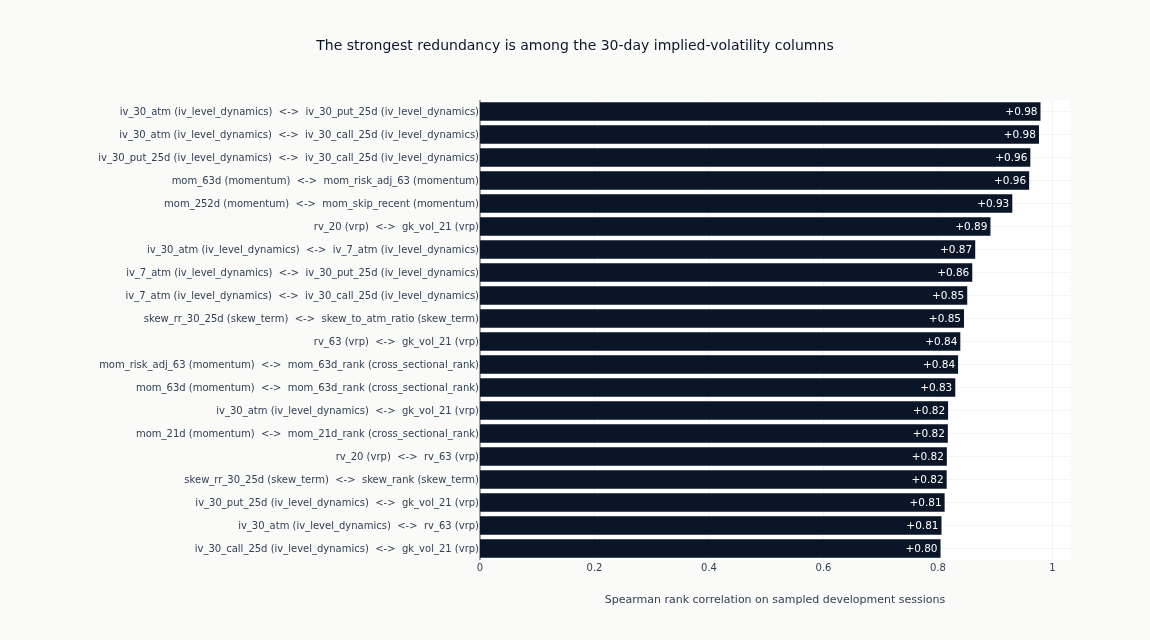

Of the 20 strongest pairs, 7 span two families


In [25]:
RANKED_PAIRS = 20
if high_corr_pairs:
    ranked = sorted(high_corr_pairs, key=lambda pair: abs(pair[2]), reverse=True)[:RANKED_PAIRS]
    pair_labels = [
        f"{left} ({families.get(left, 'other')})  <->  {right} ({families.get(right, 'other')})"
        for left, right, _ in ranked
    ]
    pair_values = [value for _, _, value in ranked]
    cross_family = sum(
        families.get(left, "other") != families.get(right, "other") for left, right, _ in ranked
    )
    fig = go.Figure(
        go.Bar(
            x=list(reversed(pair_values)),
            y=list(reversed(pair_labels)),
            orientation="h",
            marker_color=[
                COLORS["blue"] if value > 0 else COLORS["copper"] for value in reversed(pair_values)
            ],
            text=[f"{value:+.2f}" for value in reversed(pair_values)],
            textposition="inside",
        )
    )
    fig.update_layout(
        title="The strongest redundancy is among the 30-day implied-volatility columns",
        xaxis_title="Spearman rank correlation on sampled development sessions",
        height=640,
        width=1150,
        margin={"l": 480},
        showlegend=False,
    )
    fig.show()
    print(f"Of the {len(ranked)} strongest pairs, {cross_family} span two families")

## 6. Triage & Handoff

The book's Table 7.2 rule, with every bound taken from the configuration cell.
The promotion rule is a **disjunction**, so a feature reaches PROCEED on either
arm and the promoted count can exceed the count that cleared the adjustment.
Which arm fired is recorded in the ledger's `note` column.

| Decision | Criteria |
|----------|----------|
| **PROCEED** | cleared BH-FDR, **or** sign consistency at least `SIGN_CONSISTENCY_MIN` and absolute mean IC at least `IC_THRESHOLD` |
| **STOP** | failed the correctness screen: coverage below `COVERAGE_MIN`, or staleness above `STALENESS_MAX` |
| **REVISE** | everything else, including the features carrying no cross-sectional variation |

`monotonicity` is written to the ledger as evidence and is **not** read by the
rule above.

In [26]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_set
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= SIGN_CONSISTENCY_MIN and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [27]:
# Build triage ledger
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger saved: {display_path(EVAL_DIR / 'triage_ledger.parquet')}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger saved: case_studies/sp500_equity_option_analytics/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 11  │
│ REVISE   ┆ 24  │
│ STOP     ┆ 13  │
└──────────┴─────┘


In [28]:
# Save IC time series (long format)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series saved: {display_path(EVAL_DIR / 'ic_timeseries.parquet')}")

IC time series saved: case_studies/sp500_equity_option_analytics/evaluation/ic_timeseries.parquet


In [29]:
proceed_features = sorted(f for f, (d, _) in triage.items() if d == "PROCEED")
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print(triage_ledger.group_by("note").len().sort("len", descending=True))

TRIAGE SUMMARY: sp500_equity_option_analytics
  PROCEED: 11 features
  REVISE:  24 features
  STOP:    13 features
shape: (3, 2)
┌────────────────────────────┬─────┐
│ note                       ┆ len │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ not_significant_standalone ┆ 24  │
│ correctness_fail           ┆ 13  │
│ stable_and_above_threshold ┆ 11  │
└────────────────────────────┴─────┘


### The Funnel

What was searched, what survived each stage, and what each arm of the promotion
rule contributed. Drawn rather than printed, because the width of the drop
between consecutive bars is what a reader is meant to weigh, and separating the
two arms is what shows whether a rule written as a disjunction behaves like one.

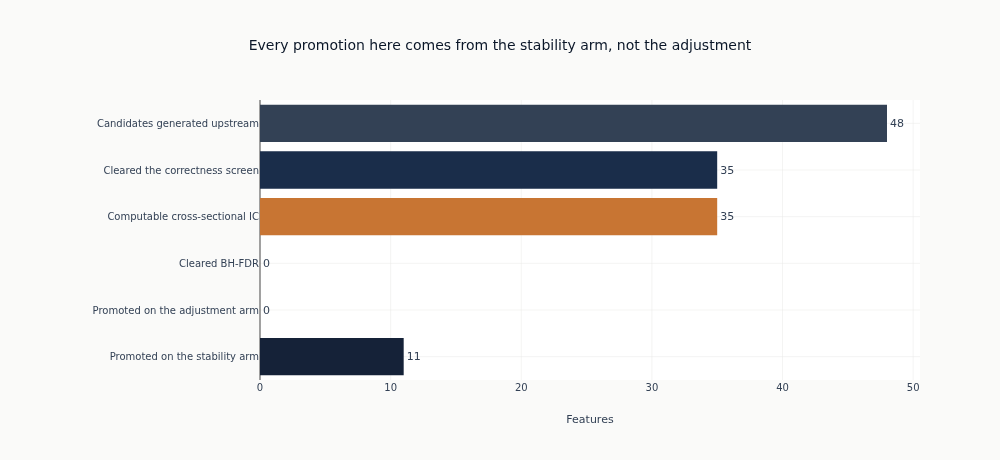

Promoted features, with the arm that promoted them:
  garch_cond_vol               IC=-0.0065  Newey-West t=-0.36  [temporal_garch, stable_and_above_threshold]
  gk_vol_21                    IC=-0.0121  Newey-West t=-0.88  [vrp, stable_and_above_threshold]
  iv_30_atm                    IC=-0.0080  Newey-West t=-0.58  [iv_level_dynamics, stable_and_above_threshold]
  iv_30_call_25d               IC=-0.0088  Newey-West t=-0.66  [iv_level_dynamics, stable_and_above_threshold]
  iv_30_put_25d                IC=-0.0089  Newey-West t=-0.65  [iv_level_dynamics, stable_and_above_threshold]
  iv_rank                      IC=-0.0080  Newey-West t=-0.58  [cross_sectional_rank, stable_and_above_threshold]
  mom_252d                     IC=+0.0118  Newey-West t=+0.63  [momentum, stable_and_above_threshold]
  mom_5d                       IC=-0.0156  Newey-West t=-1.47  [momentum, stable_and_above_threshold]
  mom_skip_recent              IC=+0.0122  Newey-West t=+0.67  [momentum, stable_and_above_t

In [30]:
arm_counts = {
    note: len([f for f, (d, n) in triage.items() if d == "PROCEED" and n == note])
    for note in ("fdr_significant", "stable_and_above_threshold")
}
funnel_stages = [
    ("Candidates generated upstream", len(all_feature_cols), COLORS["neutral"]),
    ("Cleared the correctness screen", n_pass, COLORS["slate"]),
    ("Computable cross-sectional IC", n_searched, COLORS["copper"]),
    ("Cleared BH-FDR", n_significant_fdr, COLORS["amber"]),
    ("Promoted on the adjustment arm", arm_counts["fdr_significant"], COLORS["blue"]),
    (
        "Promoted on the stability arm",
        arm_counts["stable_and_above_threshold"],
        COLORS["blue_light"],
    ),
]
fig = go.Figure(
    go.Bar(
        x=[count for _, count, _ in funnel_stages],
        y=[stage for stage, _, _ in funnel_stages],
        orientation="h",
        marker_color=[color for _, _, color in funnel_stages],
        text=[str(count) for _, count, _ in funnel_stages],
        textposition="outside",
    )
)
fig.update_layout(
    title="Every promotion here comes from the stability arm, not the adjustment",
    xaxis_title="Features",
    height=460,
    width=1000,
    margin={"l": 260, "r": 80},
    showlegend=False,
)
fig.update_yaxes(autorange="reversed")
fig.show()
print("Promoted features, with the arm that promoted them:")
for f in proceed_features:
    print(
        f"  {f:28s} IC={ic_results[f]['mean_ic']:+.4f}"
        f"  Newey-West t={ic_results[f]['t_stat']:+.2f}"
        f"  [{families.get(f, '?')}, {triage[f][1]}]"
    )

## Key Takeaways

### What the screen does

1. **Seal first.** Every statistic above is computed on development sessions
   only, with the last `LABEL_HORIZON_SESSIONS` of them embargoed so no forward
   label settles across the boundary. The holdout is spent once, later, on one
   model.
2. **Screen the definition before the signal.** Coverage and staleness are
   properties a feature has whether or not it predicts anything, and a stale
   column can carry an IC that is an artifact of the carry-forward.
3. **Declare the searched set before the p-value.** The adjustment is
   interpretable only against the set of tests it came from, and that set is
   fixed by the upstream generation rules, not by what this notebook found.
4. **A weak result is a result.** Implied volatility predicts future realized
   volatility, not the direction of the underlying. Reporting that plainly is the
   point of a univariate screen; whatever these features contribute is expected
   to appear in a multivariate fit, and this notebook does not test that claim.

### Known limitations of this screen

- Fold stability is measured on the producer folds' validation windows, which
  cover the later part of the development window rather than all of it, because
  a walk-forward scheme spends its early sessions training. The overall IC in
  section 2 spans more sessions than these folds do, and the two are not
  expected to agree exactly.
- The three GARCH columns exist only inside those validation windows, so they
  are screened on that window rather than on the whole panel. Their coverage is
  not comparable to a financial column's. Their IC is measured on those sessions
  too, so the searched set the adjustment is applied across does not rest on one
  common span.
- The stability arm is a two-fold test. With `n_splits` at two it promotes a
  feature when both validation folds share its sign and nothing more, which is
  the weakest reading the `sign_consistency` column supports, and in this run it
  is the only arm that promoted anything.
- Quantile bins are assigned over the pooled sample rather than within each
  session.
- The IC is screened on the primary label only. The case study ships a ten-session
  forward return and a risk-adjusted five-session variant, and neither is
  evaluated here, so the horizon profile book §7.3 asks for is not drawn.
- Univariate triage is necessary and not sufficient; nothing here claims
  tradability.

**Next**: `06_linear.py` tests whether these features add incremental value
beyond price-only features in a multivariate ridge model.